<div style="background: linear-gradient(135deg, #1a0000 0%, #8B0000 50%, #FF4500 100%); padding: 40px 35px; border-radius: 20px; text-align: center; margin-bottom: 20px; box-shadow: 0 10px 40px rgba(255,69,0,0.45);">
  <h1 style="color: white; font-size: 2.8em; margin: 0; letter-spacing: 3px; font-weight: 700;">Détection d'Incendies & de Fumée</h1>
  <h2 style="color: #FFD700; font-size: 1.5em; margin-top: 14px; font-weight: 400; letter-spacing: 1px;">YOLO26s &nbsp;|&nbsp; Dataset D-Fire &nbsp;|&nbsp; Multi-GPU Training</h2>
  <hr style="border: 1px solid rgba(255,255,255,0.25); margin: 18px 0;">
  <p style="color: #FFE4B5; font-size: 1.05em; margin: 0; font-style: italic;">Cycle complet du projet Deep Learning — Présentation Académique</p>
  <div style="margin-top: 18px; display: flex; justify-content: center; gap: 16px; flex-wrap: wrap;">

  </div>
</div>

---

## Table des Matières

| # | Section | Description |
|:-:|---------|-------------|
| **1** | Environnement & Installation | Vérification GPU, dépendances |
| **2** | Dataset D-Fire | Présentation, téléchargement, configuration |
| **3** | Exploration des Données (EDA) | Analyse statistique, visualisation des annotations |
| **4** | Architecture du Modèle | YOLO26s — justification du choix |
| **5** | Entraînement | Code d'entraînement complet (Multi-GPU) |
| **6** | Résultats d'Entraînement | Courbes, métriques, confusion matrix |
| **7** | Évaluation sur Test Set | Évaluation formelle & tableau final |
| **8** | Inférence | Prédictions sur images & vidéos |
| **9** | Conclusion & Perspectives | Synthèse, export |

---

## 1. Environnement & Installation

<div style="background: #f0f4ff; border-left: 5px solid #4a90d9; padding: 14px 18px; border-radius: 6px; margin: 10px 0; color: #1a1a2e;">
  <strong>Plateforme d'entraînement :</strong> Kaggle Notebooks — 2× GPU T4 (16 GB chacun)<br>
  <strong>Plateforme de présentation :</strong> Google Colab — GPU T4
</div>

### 1.1 Vérification du GPU

Avant toute chose, on vérifie que le GPU est bien disponible et que les bibliothèques sont correctement installées.

In [ ]:
# 1.2  Installation des dépendances
%pip install ultralytics --quiet
%pip install seaborn matplotlib pandas numpy Pillow opencv-python-headless --quiet
print("Toutes les dépendances sont installées.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.6 MB/s eta 0:00:00
Toutes les dépendances sont installées.


In [ ]:

# 1.3  Imports & configuration globale

import os, glob, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from pathlib import Path
from PIL import Image
from IPython.display import display
from google.colab import files

import torch
from ultralytics import YOLO

# ── Style graphique global ──────────────────────────────────
DARK_BG   = '#0d1117'
PANEL_BG  = '#161b22'
ACCENT    = '#FF4500'
GOLD      = '#FFD700'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,
    'axes.facecolor':   PANEL_BG,
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'legend.facecolor': '#21262d',
    'legend.edgecolor': '#30363d',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

CLASS_NAMES  = {0: 'fire', 1: 'smoke'}
CLASS_COLORS = {0: '#FF4500', 1: '#708090'}

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {'disponible — ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'non disponible'}")
print(f"Imports  : OK")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch  : 2.10.0+cu128
CUDA     : disponible — Tesla T4
Imports  : OK


---

## 2. Dataset D-Fire

### 2.1 Présentation du Dataset

**D-Fire** est un dataset public conçu spécifiquement pour la détection précoce d'incendies par vision par ordinateur. Il couvre une grande diversité de scènes : forêts, bâtiments industriels, zones urbaines, intérieurs.

| Propriété | Détail |
|:----------|:-------|
| Images totales | ~21 000 images |
| Classes | `fire` (flammes visibles) — `smoke` (fumée) |
| Format | YOLO `.txt` (cx, cy, w, h normalisés) |
| Variété | Jour / nuit, drone, caméra fixe, intérieur |
| Split | Train 70% — Val 20% — Test 10% |

### 2.2 Enjeu Applicatif

<div style="background: #fff8e1; border-left: 5px solid #f59e0b; padding: 14px 18px; border-radius: 6px; margin: 10px 0; color: #2d2000;">
Détecter la <strong>fumée</strong> avant l'apparition des flammes permet une intervention jusqu'à <strong>10× plus rapide</strong>. Le modèle cible un usage temps réel sur drones et caméras de surveillance.
</div>

### 2.3 Téléchargement & Statistiques

100%|██████████| 2.84G/2.84G [02:38<00:00, 19.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shubhamkarande13/d-fire/versions/1

RÉSUMÉ STATISTIQUE
Class     0      1  Total
Split                    
test   2315   2878   5193
train  9550  11814  21364


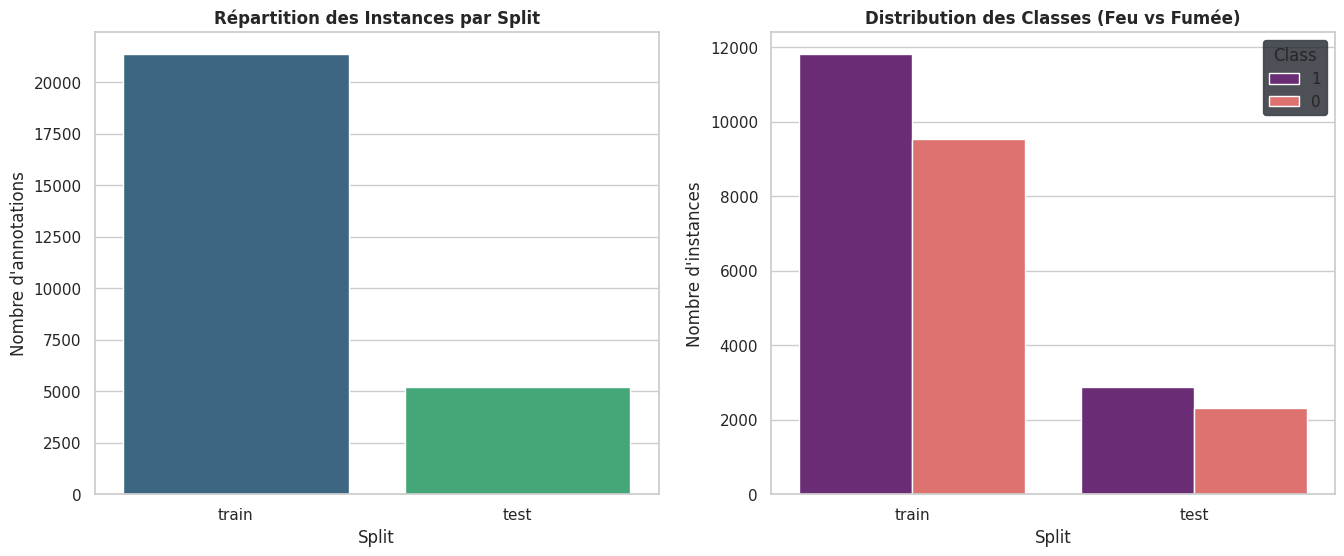

In [ ]:
import kagglehub

# 2.3  Téléchargement du dataset via KaggleHub
path = kagglehub.dataset_download("shubhamkarande13/d-fire")

print("Path to dataset files:", path)
# ── Comptage des fichiers ─────────────────────────────────────
# 1. Extraction des données
def collect_detailed_stats(base_path):
    data = []
    # On cherche le fichier data.yaml pour les noms de classes
    yaml_path = os.path.join(base_path, 'data.yaml')
    class_names = []
    if os.path.exists(yaml_path):
        with open(yaml_path, 'r') as f:
            config = yaml.safe_load(f)
            class_names = config.get('names', [])

    for split in ['train', 'valid', 'test']:
        label_path = os.path.join(base_path, split, 'labels')
        if os.path.exists(label_path):
            for file in os.listdir(label_path):
                if file.endswith('.txt'):
                    with open(os.path.join(label_path, file), 'r') as f:
                        lines = f.readlines()
                        for line in lines:
                            class_id = int(line.split()[0])
                            class_label = class_names[class_id] if class_id < len(class_names) else str(class_id)
                            data.append({'Split': split, 'Class': class_label})
    return pd.DataFrame(data)

df = collect_detailed_stats(path)

# 2. Création des graphiques
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Graphique A : Répartition Train/Valid/Test (Volume global)
sns.countplot(data=df, x='Split', hue='Split', ax=ax[0], palette='viridis', legend=False)
ax[0].set_title('Répartition des Instances par Split', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Nombre d\'annotations')

# --- Graphique B : Distribution des classes ---
# Ici, hue='Class' est déjà présent, donc pas d'avertissement
sns.countplot(data=df, x='Split', hue='Class', ax=ax[1], palette='magma')
ax[1].set_title('Distribution des Classes (Feu vs Fumée)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('Nombre d\'instances')

# 3. Résumé textuel propre pour le Notebook
print("\n" + "="*30)
print("RÉSUMÉ STATISTIQUE")
print("="*30)
pivot_table = df.pivot_table(index='Split', columns='Class', aggfunc='size', fill_value=0)
pivot_table['Total'] = pivot_table.sum(axis=1)
print(pivot_table)

---

## 3. Exploration des Données (EDA)

L'analyse exploratoire permet de comprendre la distribution des classes, la géométrie des annotations et les biais potentiels avant l'entraînement.

### 3.1 Répartition des Labels & Géométrie des Bounding Boxes

Analyse de la répartition des instances de feu et de fumée dans le dataset d'origine.

 Analyse des annotations en cours...



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_stats, x='class_name', ax=axes[0], palette=['#7f8c8d', '#e74c3c'])



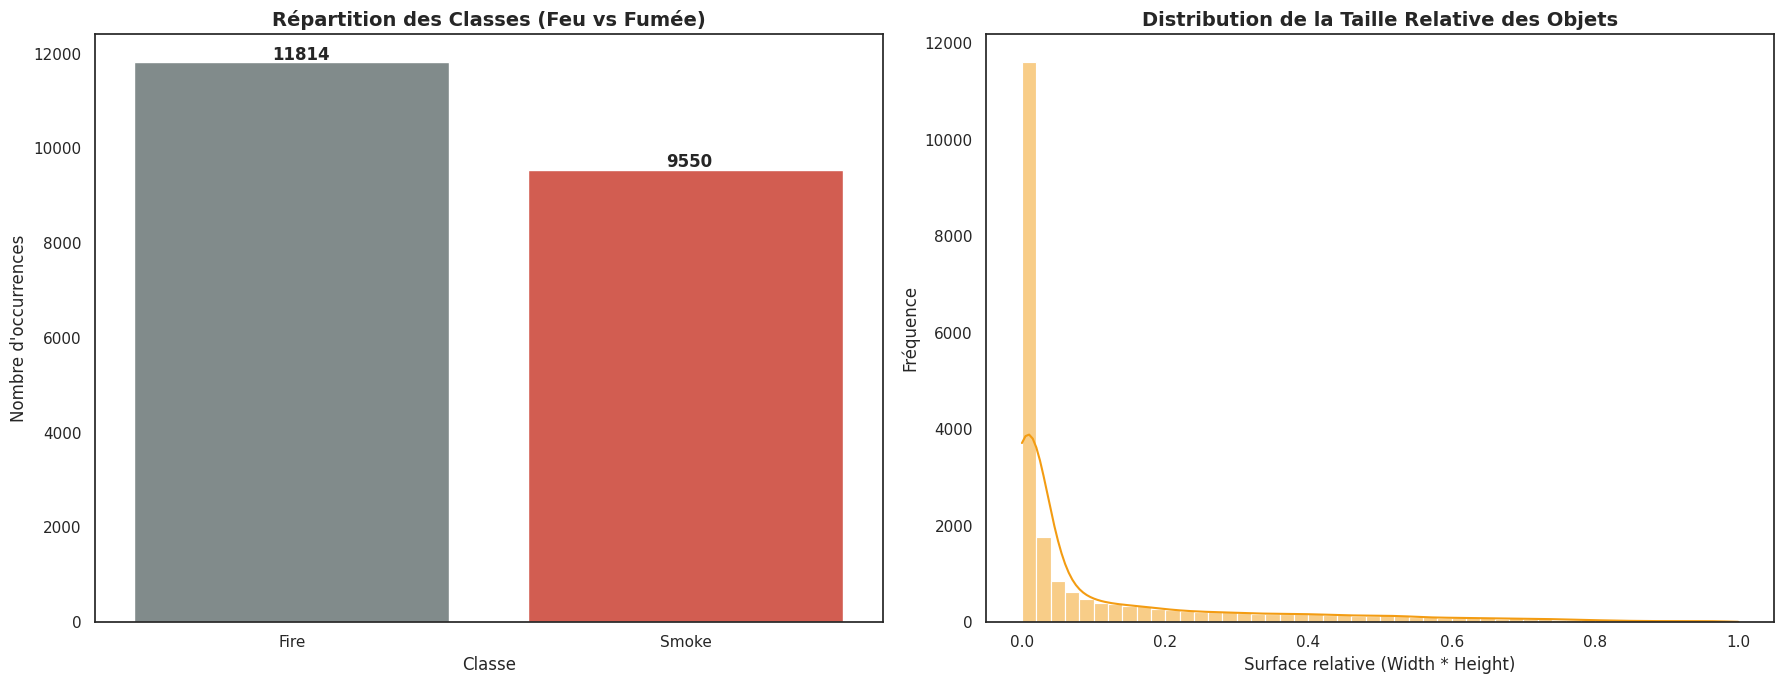

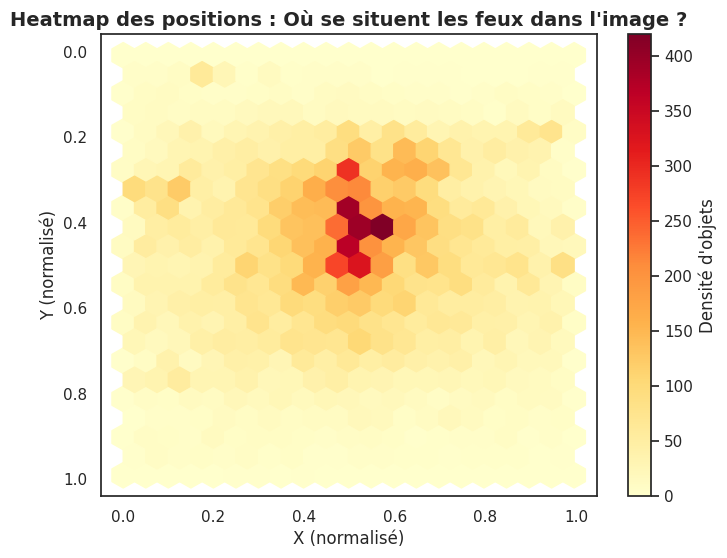

 Analyse terminée sur 21364 annotations.


In [ ]:

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration du chemin ---
DATASET_PATH = "/root/.cache/kagglehub/datasets/shubhamkarande13/d-fire/versions/1"
TRAIN_LBL_DIR = os.path.join(DATASET_PATH, "train/labels")

def analyze_dataset(label_dir):
    stats = []
    for lbl_file in Path(label_dir).glob("*.txt"):
        with open(lbl_file, "r") as f:
            for line in f.readlines():
                parts = line.split()
                if len(parts) == 5:
                    cls, x, y, w, h = map(float, parts)
                    stats.append({
                        'class': int(cls),
                        'x_center': x,
                        'y_center': y,
                        'width': w,
                        'height': h,
                        'area': w * h
                    })
    return pd.DataFrame(stats)

# 1. Extraction des statistiques
print(" Analyse des annotations en cours...")
df_stats = analyze_dataset(TRAIN_LBL_DIR)

# 2. Mapping des noms de classes (à ajuster selon votre YAML)
class_map = {0: 'Smoke', 1: 'Fire'}
df_stats['class_name'] = df_stats['class'].map(class_map)

# 3. Visualisation Professionnelle
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Graphe A : Répartition des classes ---
sns.countplot(data=df_stats, x='class_name', ax=axes[0], palette=['#7f8c8d', '#e74c3c'])
axes[0].set_title("Répartition des Classes (Feu vs Fumée)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Nombre d'occurrences")

# Ajout des compteurs sur les barres
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+0.35, p.get_height()+50), fontweight='bold')

# --- Graphe B : Distribution des tailles des boîtes ---
sns.histplot(data=df_stats, x='area', bins=50, ax=axes[1], color='#f39c12', kde=True)
axes[1].set_title("Distribution de la Taille Relative des Objets", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Surface relative (Width * Height)")
axes[1].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

# --- Graphe C : Position des boîtes (Heatmap) ---
plt.figure(figsize=(8, 6))
plt.hexbin(df_stats['x_center'], df_stats['y_center'], gridsize=20, cmap='YlOrRd')
plt.colorbar(label='Densité d\'objets')
plt.title("Heatmap des positions : Où se situent les feux dans l'image ?", fontsize=14, fontweight='bold')
plt.xlabel("X (normalisé)")
plt.ylabel("Y (normalisé)")
plt.gca().invert_yaxis() # Pour correspondre à l'orientation des pixels (0,0 en haut à gauche)
plt.show()

print(f" Analyse terminée sur {len(df_stats)} annotations.")

### 3.3 Distribution des Tailles de Bounding Boxes

Distribution en largeur et hauteur des boîtes de détection pour les deux classes.

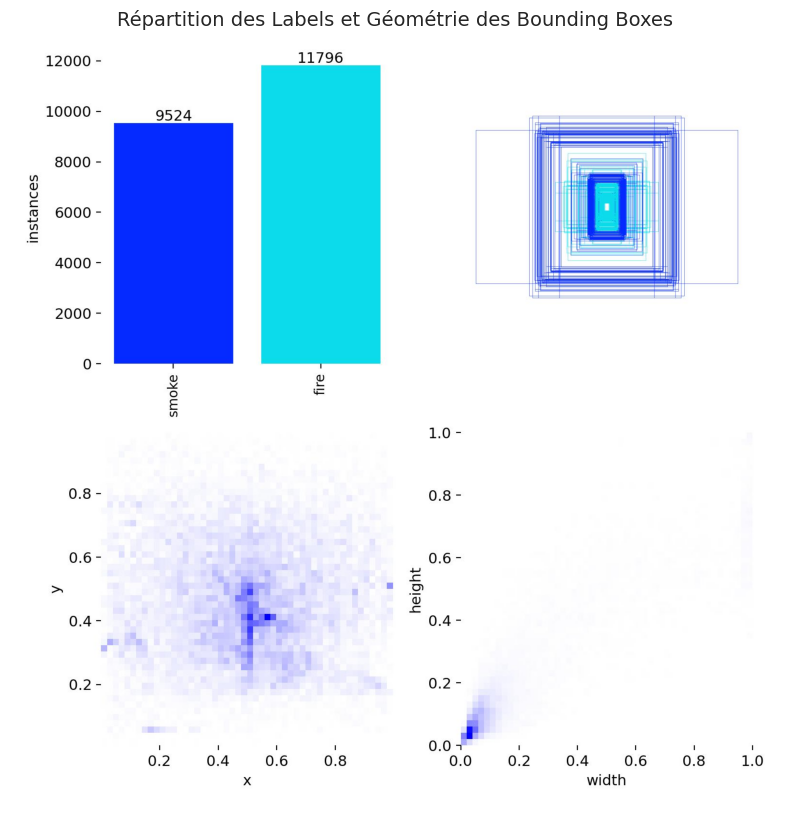

In [ ]:
import matplotlib.pyplot as plt
import cv2

# 3.1  Labels générés par YOLO lors de l'analyse initiale
img = cv2.imread('labels.jpg')
plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Répartition des Labels et Géométrie des Bounding Boxes", fontsize=14)
plt.axis('off')
plt.show()

Exploration Visuelle des Données du dataset

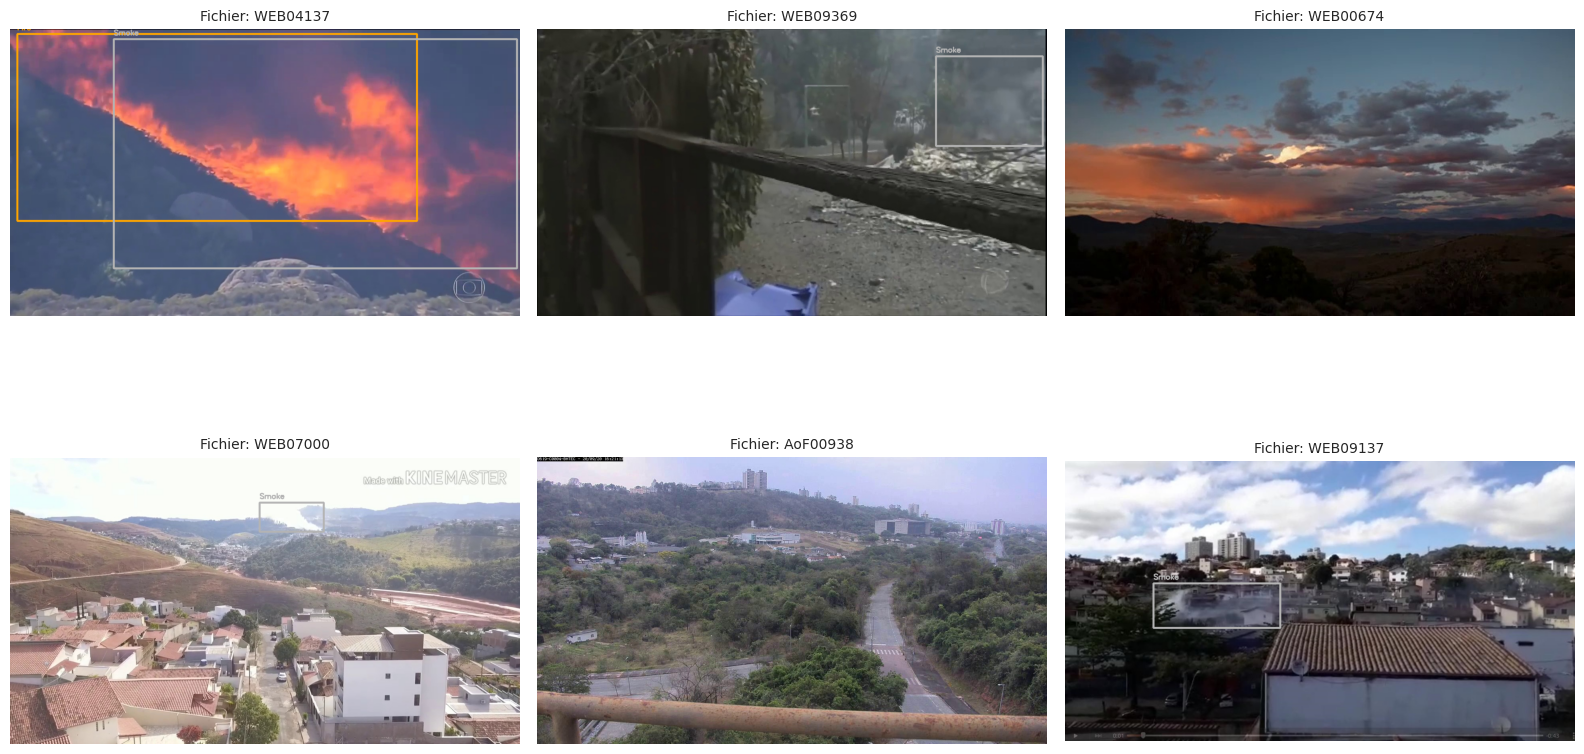

In [ ]:

import cv2
import os
import random
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration des chemins ---
DATASET_PATH = "/root/.cache/kagglehub/datasets/shubhamkarande13/d-fire/versions/1"
TRAIN_IMG = os.path.join(DATASET_PATH, "train/images")
TRAIN_LBL = os.path.join(DATASET_PATH, "train/labels")

def draw_boxes(img_path, lbl_path):
    img = cv2.imread(str(img_path))
    if img is None: return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as f:
            for line in f.readlines():
                parts = line.split()
                if len(parts) == 5:
                    cls, x, y, bw, bh = map(float, parts)
                    # Conversion YOLO (normalisé 0-1) -> Pixels
                    x1 = int((x - bw/2) * w)
                    y1 = int((y - bh/2) * h)
                    x2 = int((x + bw/2) * w)
                    y2 = int((y + bh/2) * h)

                    # Orange pour Fire (1), Gris pour Smoke (0)
                    color = (255, 165, 0) if int(cls) == 1 else (180, 180, 180)
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)

                    # Optionnel : Ajouter le nom de la classe au-dessus de la box
                    label = "Fire" if int(cls) == 1 else "Smoke"
                    cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return img

def show_grid(image_folder, n=6):
    # Récupération de la liste des images
    images_list = list(Path(image_folder).glob('*.jpg')) + list(Path(image_folder).glob('*.png'))

    if not images_list:
        print(f" Aucune image trouvée dans {image_folder}")
        return

    sample = random.sample(images_list, min(n, len(images_list)))
    plt.figure(figsize=(16, 10))

    for i, img_path in enumerate(sample):
        name = img_path.stem
        lbl_path = os.path.join(TRAIN_LBL, name + ".txt")

        img_result = draw_boxes(img_path, lbl_path)

        if img_result is not None:
            plt.subplot(2, 3, i + 1)
            plt.imshow(img_result)
            plt.title(f"Fichier: {name}", fontsize=10)
            plt.axis("off")

    plt.tight_layout()
    plt.show()

# Lancement de la visualisation
show_grid(TRAIN_IMG)

### 3.2 Visualisation des Données Augmentées

Pour améliorer la robustesse du modèle face aux variations de contexte, nous avons appliqué des techniques d'augmentation : Mosaic, flous, changements de luminosité, rotations.

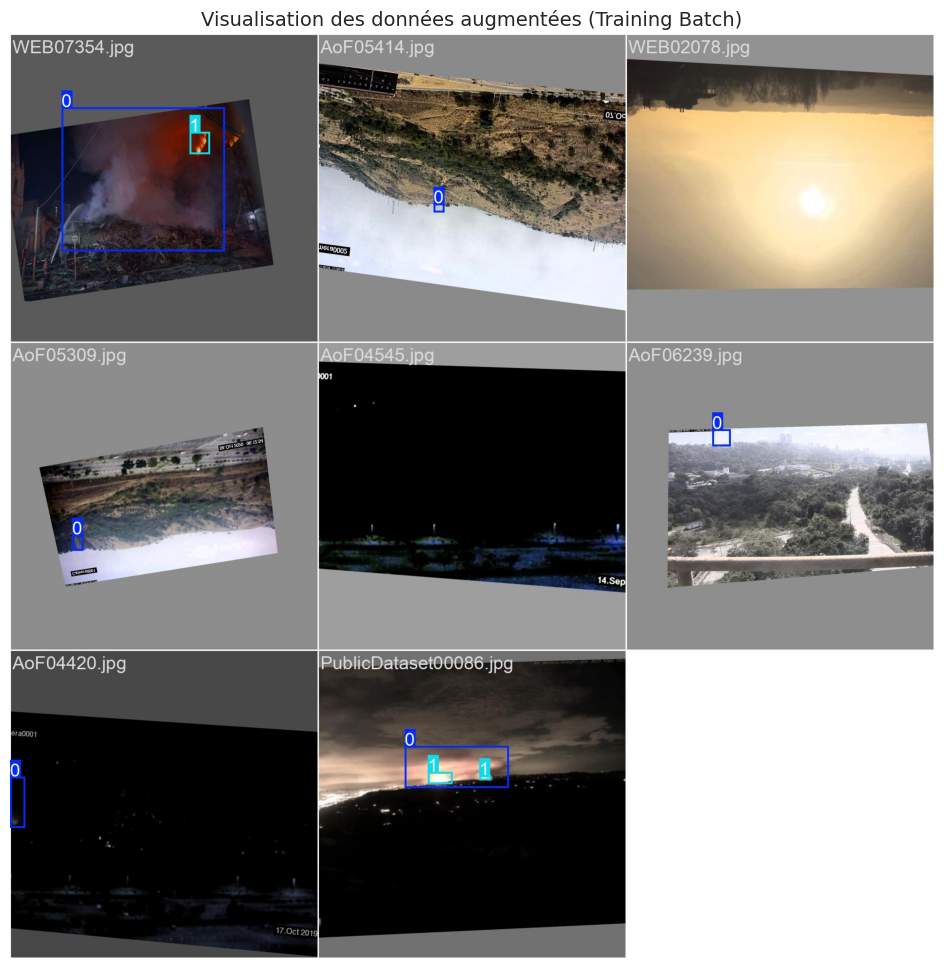

In [ ]:
# 3.2  Visualisation d'un batch d'entraînement augmenté
img_aug = cv2.imread('train_batch96750.jpg')
plt.figure(figsize=(15, 12))
plt.imshow(cv2.cvtColor(img_aug, cv2.COLOR_BGR2RGB))
plt.title("Visualisation des données augmentées (Training Batch)", fontsize=14)
plt.axis('off')
plt.show()

---

## 4. Architecture du Modèle — YOLO26s

### 4.1 Pourquoi YOLO ?

YOLO (*You Only Look Once*) effectue la détection en un **seul passage** du réseau, rendant possible la détection temps réel — critique pour les systèmes d'alerte incendie.

### 4.2 Justification du Choix — YOLO26s

| Variante | Params | mAP COCO | Vitesse | Choix |
|----------|-------:|---------:|--------:|:-----:|
| YOLO26n  |  3.1 M |   37.0   | ████████|       |
| **YOLO26s** | **11.4 M** | **45.2** | **███████** | **[x]** |
| YOLO26m  | 26.4 M |   50.7   | █████   |       |
| YOLO26l  | 44.0 M |   53.0   | ████    |       |

**Avantages clés de YOLO26s pour ce projet :**
- Tête de détection **découplée** — meilleure convergence
- **Anchor-free** — généralisation accrue sur objets de tailles variées
- Résolution **1280×1280** — détection de petites fumées distantes
- Optimisé **Multi-GPU** natif

### 4.3 Pipeline de Traitement

```
Image 1280x1280
      |
  Backbone (CSPDarknet + C2f)
      |
  Neck (FPN + PAN)
      |
  Head (Detect — 3 echelles)
      |
  NMS  ->  Predictions finales [ fire | smoke ]
```

---

## 5. Entraînement du Modèle

<div style="background: #f0fff4; border-left: 5px solid #38a169; padding: 14px 18px; border-radius: 6px; margin: 10px 0; color: #1a2e1a;">
  <strong>Note :</strong> L'entraînement a été réalisé sur <strong>Kaggle</strong> (2× GPU T4 16 GB).<br>
  Cette section présente le code exact utilisé. Sur Colab (1× T4), le modèle pré-entraîné est chargé directement en section 6.
</div>

### 5.1 Stratégie d'Entraînement

| Hyperparamètre | Valeur | Justification |
|:---------------|:------:|:--------------|
| `imgsz` | 1280 | Détection fine des petits foyers |
| `epochs` | 100 | Convergence complète avec patience |
| `batch` | 16 | Multiple de 2 GPUs  (GPU 2X T4) |
| `patience` | 30 | Early stopping anti-surapprentissage |
| `mosaic` | 1.0 | Augmentation variété de scènes |
| `mixup` | 0.2 | Régularisation par interpolation |
| `device` | [0, 1] | Parallélisme multi-GPU DDP |

### 5.2 Code d'Entraînement

In [ ]:
from ultralytics import YOLO


model = YOLO('yolo26s.pt')


results = model.train(
    data='/kaggle/working/fire_config.yaml',
    epochs=100,
    imgsz=1280,


    device=[0, 1],
    batch=16,

    patience=30,

    mosaic=1.0,           # Combinaison de 4 images
    mixup=0.2,            # Mélange inter-images
    degrees=10.0,         # Rotation aléatoire ±10°
    perspective=0.0001,   # Légère déformation perspective
    flipud=0.5,           # Retournement vertical
    fliplr=0.5,           # Retournement horizontal

    # ── Sauvegarde ──────────────────────────────────────────
    project='D-Fire_Project',
    name='YOLO26s_1280_MultiGPU',
    save=True,
)

##Visualisation des Batches (Entraînement vs Validation)


════════════════════════════════════════════════════════════
 ÉTAPE D'AUGMENTATION DES DONNÉES (MOSAIC)
════════════════════════════════════════════════════════════
 Fichiers manquants pour la comparaison : train_batch96750.jpg ou train_batch1.jpg

════════════════════════════════════════════════════════════
 VALIDATION : VÉRITÉ TERRAIN vs PRÉDICTIONS
════════════════════════════════════════════════════════════


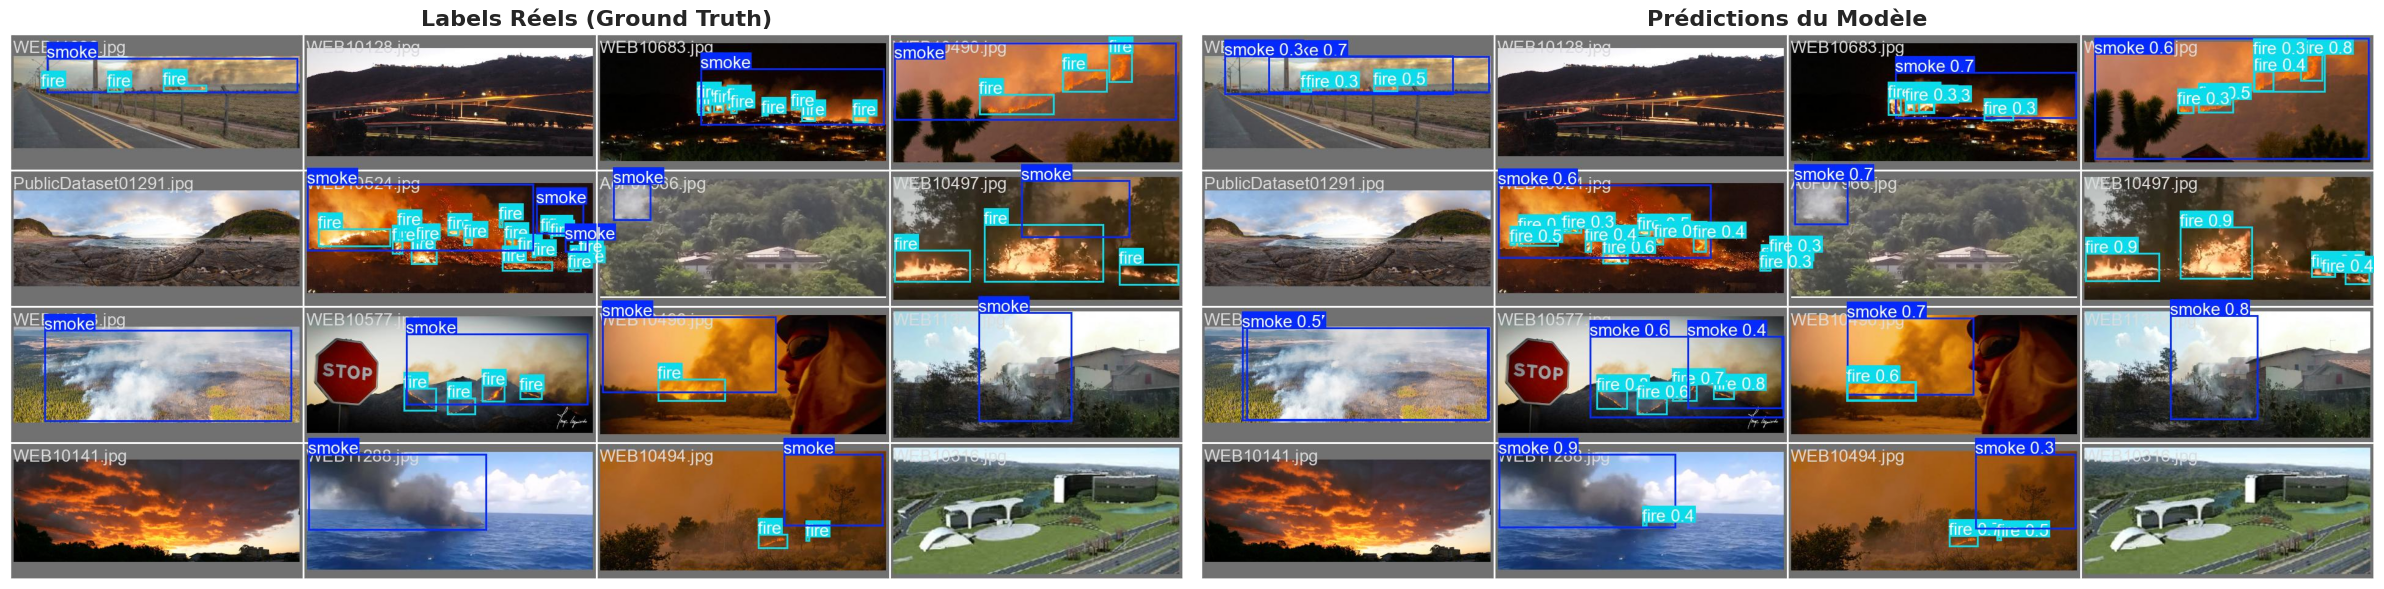

In [ ]:

import matplotlib.pyplot as plt
import cv2
import os

def afficher_comparaison_batches(file1, title1, file2, title2):
    if os.path.exists(file1) and os.path.exists(file2):
        fig, axes = plt.subplots(1, 2, figsize=(24, 12))

        # Image 1
        img1 = cv2.imread(file1)
        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
        axes[0].imshow(img1)
        axes[0].set_title(title1, fontsize=16, fontweight='bold')
        axes[0].axis('off')

        # Image 2
        img2 = cv2.imread(file2)
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
        axes[1].imshow(img2)
        axes[1].set_title(title2, fontsize=16, fontweight='bold')
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print(f" Fichiers manquants pour la comparaison : {file1} ou {file2}")

# --- 1. Visualisation de l'Augmentation (Training) ---
print("\n" + "═"*60)
print(" ÉTAPE D'AUGMENTATION DES DONNÉES (MOSAIC)")
print("═"*60)
# Remplace par le nom exact de ton fichier de batch d'entraînement
afficher_comparaison_batches('train_batch96750.jpg', "Mosaïque d'entraînement (Data Augmentation)",
                             'train_batch1.jpg', "Variations de contexte (Batch 1)")

# --- 2. Comparaison Validation (Réalité vs Prédiction) ---
print("\n" + "═"*60)
print(" VALIDATION : VÉRITÉ TERRAIN vs PRÉDICTIONS")
print("═"*60)
# Très important pour montrer que le modèle détecte ce qu'il est censé détecter
afficher_comparaison_batches('val_batch0_labels.jpg', "Labels Réels (Ground Truth)",
                             'val_batch0_pred.jpg', "Prédictions du Modèle")

---

## 6. Résultats d'Entraînement

### 6.1 Courbes d'Evolution — Loss & mAP

Visualisation de l'évolution des pertes et des métriques de performance au fil des 100 époques d'entraînement.

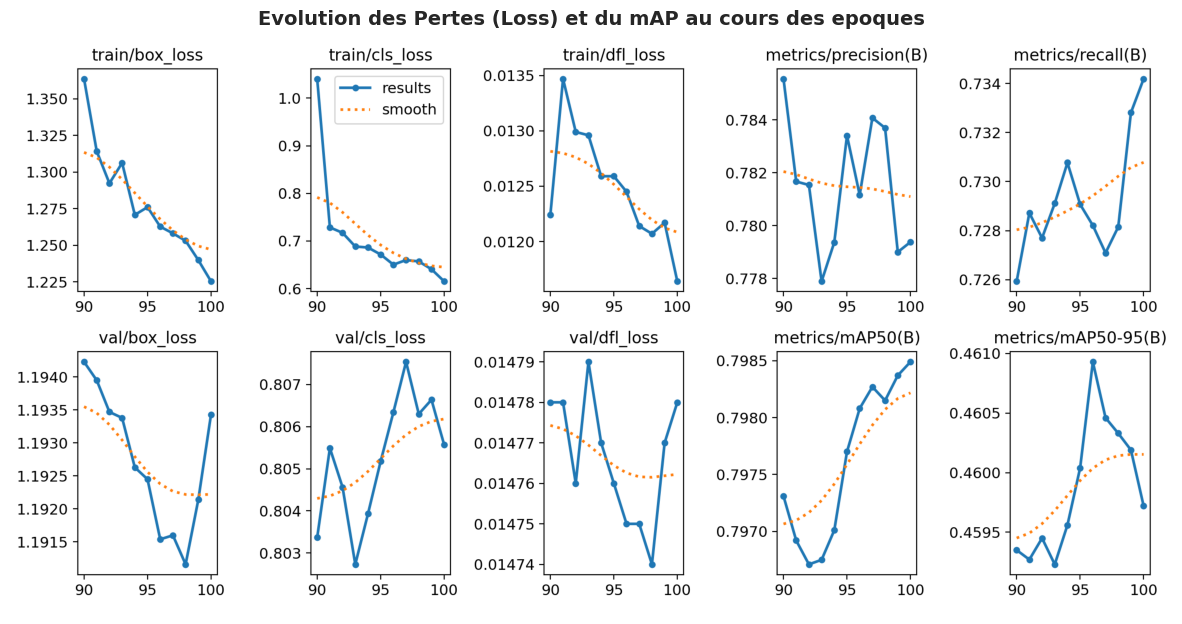

In [ ]:
img_res = cv2.imread('results.png')
plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB))
plt.title("Evolution des Pertes (Loss) et du mAP au cours des epoques", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

### 6.2 Matrice de Confusion

La matrice de confusion permet d'identifier les confusions entre classes et les faux positifs/négatifs du modèle.

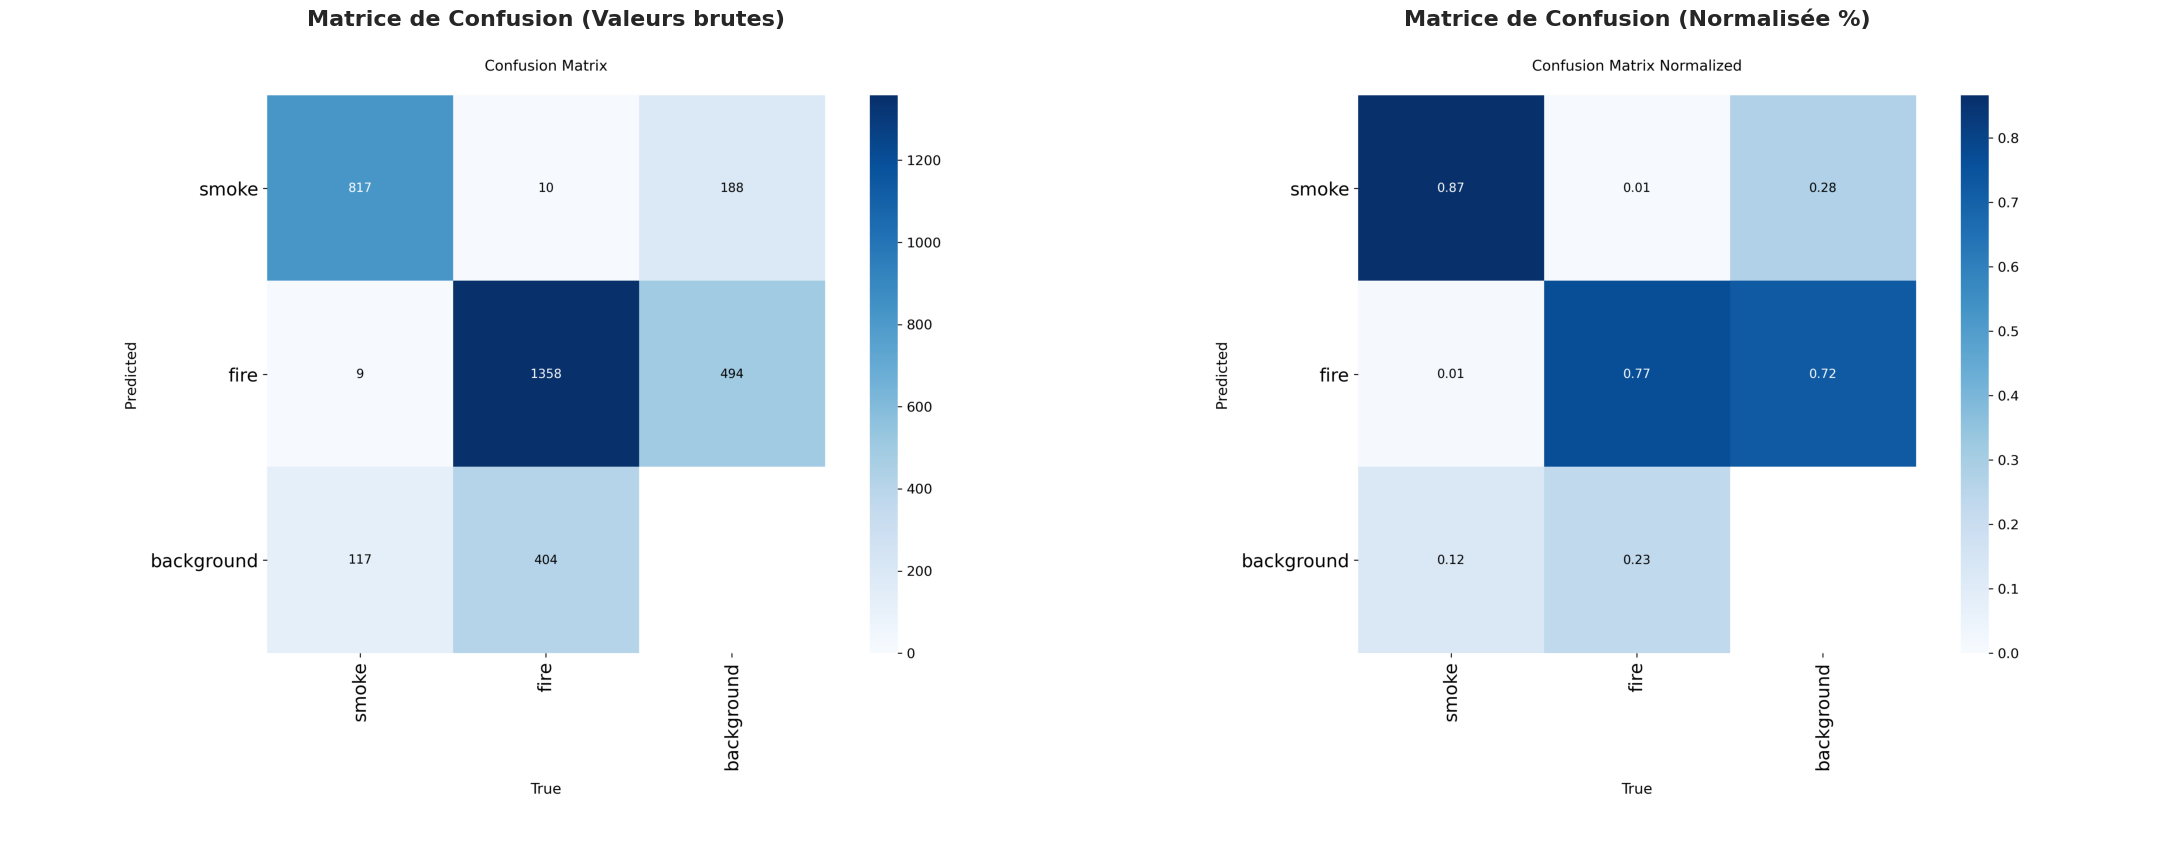

 Affichage comparatif des matrices terminé.


In [ ]:
 cv2
import os

# Fichiers sources
file_raw = 'confusion_matrix.png'
file_norm = 'confusion_matrix_normalized.png'

# Vérification de la présence des deux fichiers
if os.path.exists(file_raw) and os.path.exists(file_norm):
    # Création d'une figure avec 1 ligne et 2 colonnes
    fig, axes = plt.subplots(1, 2, figsize=(22, 10))

    # 1. Matrice de Confusion Brute
    img1 = cv2.imread(file_raw)
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    axes[0].imshow(img1)
    axes[0].set_title("Matrice de Confusion (Valeurs brutes)", fontsize=16, fontweight='bold', pad=15)
    axes[0].axis('off')

    # 2. Matrice de Confusion Normalisée
    img2 = cv2.imread(file_norm)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    axes[1].imshow(img2)
    axes[1].set_title("Matrice de Confusion (Normalisée %)", fontsize=16, fontweight='bold', pad=15)
    axes[1].axis('off')

    # Ajustement de l'espace entre les images
    plt.tight_layout()
    plt.show()

    print(" Affichage comparatif des matrices terminé.")
else:
    print(" Erreur : L'un des fichiers de matrice est manquant dans /content/")

---

## 7. Evaluation sur Test Set

### 7.1 Courbes Précision / Rappel

Analyse comparative des performances du modèle sur le jeu de test.

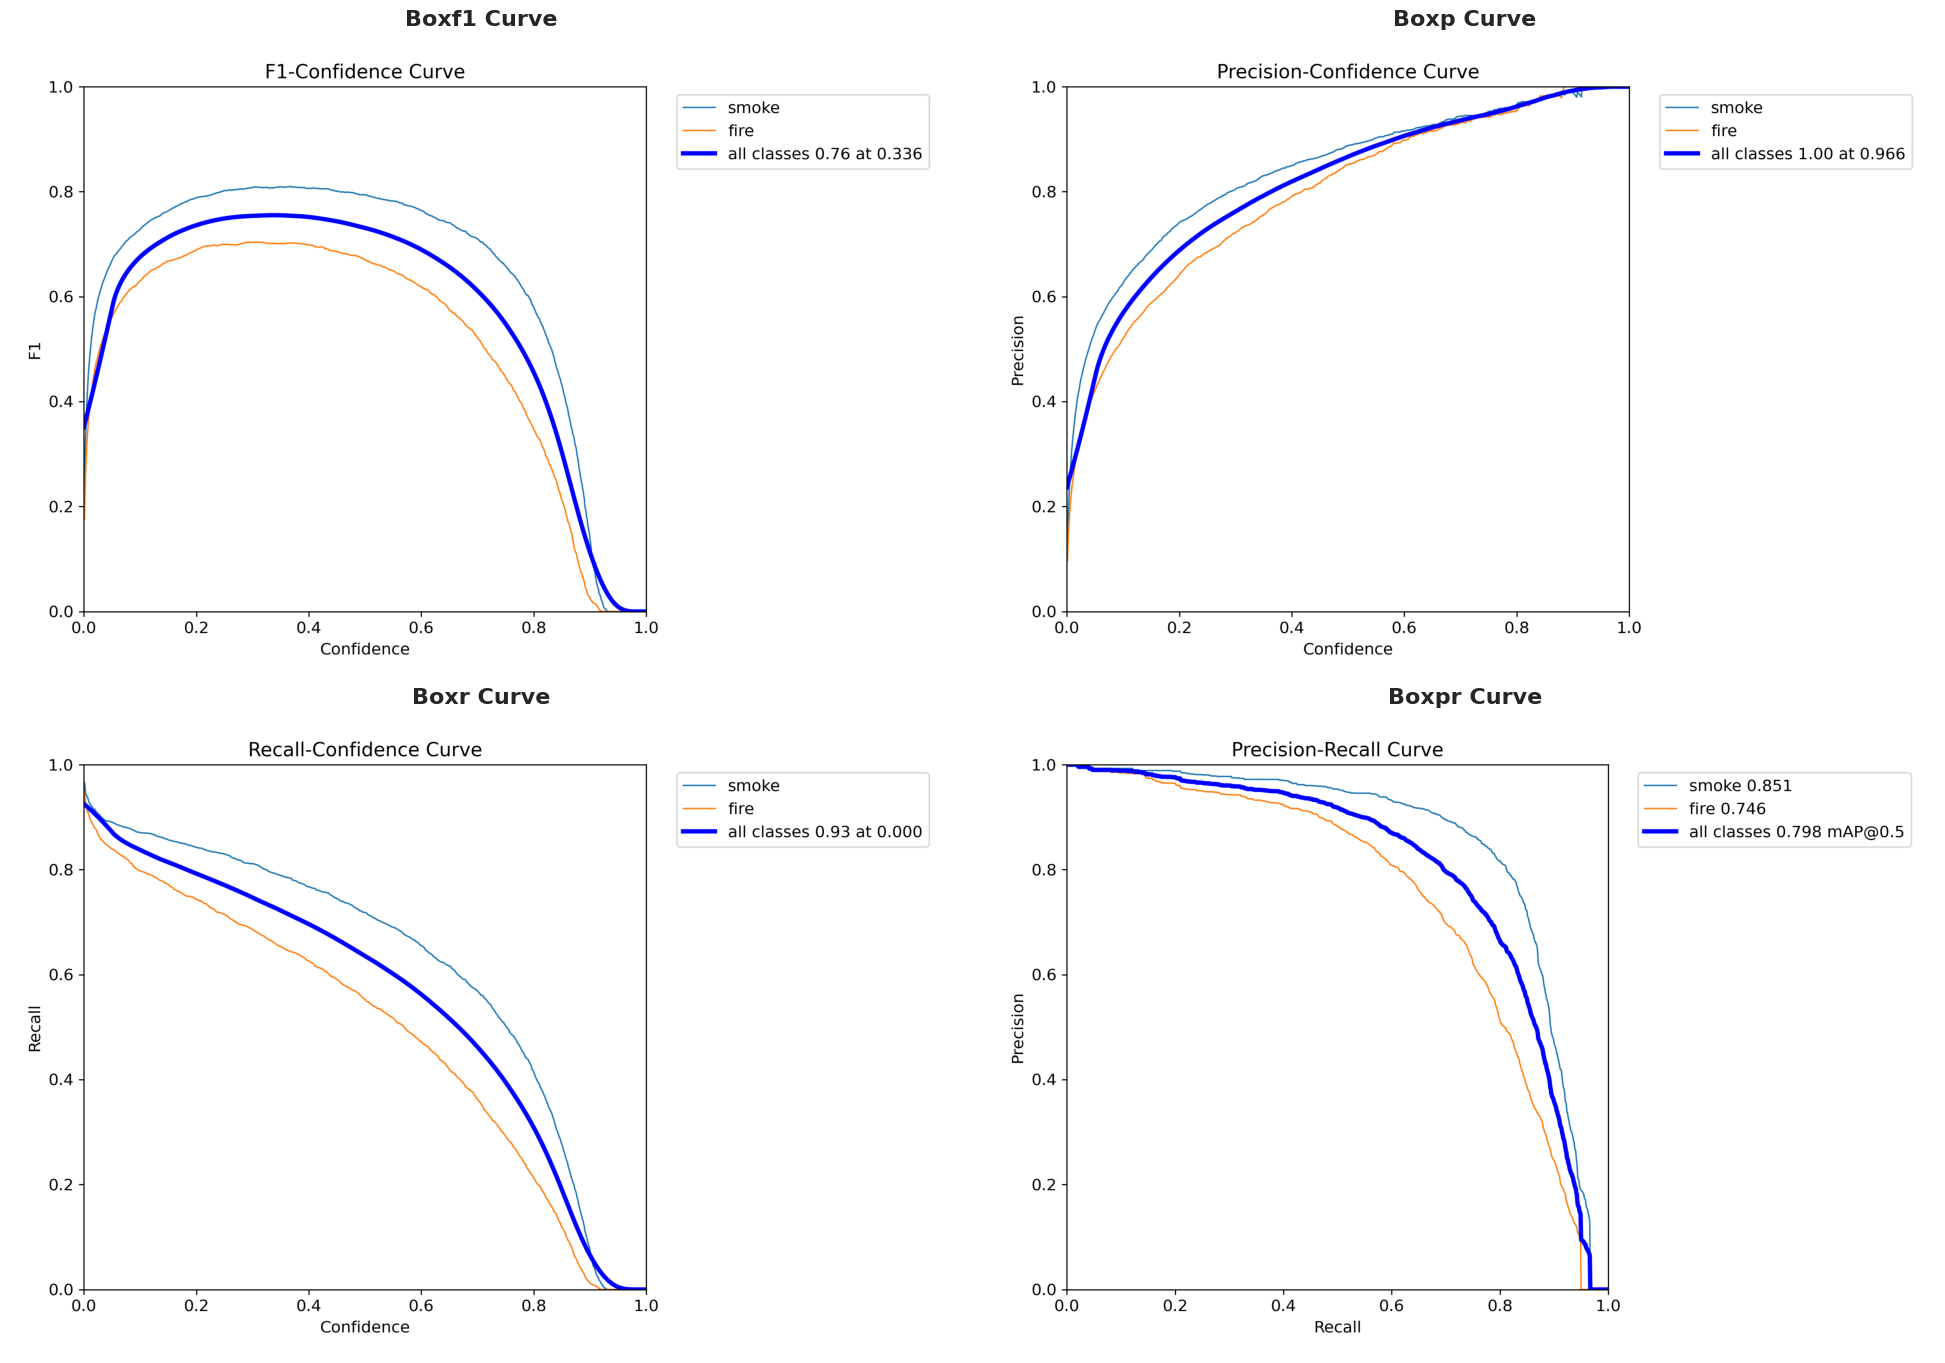

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Liste des fichiers à afficher
curve_files = ["BoxF1_curve.png", "BoxP_curve.png", "BoxR_curve.png", "BoxPR_curve.png"]

# Configuration de la figure
plt.figure(figsize=(20, 14)) # Taille agrandie pour une meilleure lisibilité

for i, f in enumerate(curve_files):
    # Si les fichiers sont à la racine, path = f
    # Si ils sont dans un dossier spécifique, utilisez RUN_DIR
    path = f

    if os.path.exists(path):
        img = mpimg.imread(path)
        plt.subplot(2, 2, i + 1)
        plt.imshow(img)

        # Nettoyage du titre (ex: BoxPR_curve -> BoxPR Curve)
        title_clean = f.replace(".png", "").replace("_", " ").title()
        plt.title(title_clean, fontsize=16, fontweight='bold', pad=15)
        plt.axis("off")
    else:
        print(f" Fichier manquant : {f}")

plt.tight_layout(pad=2.0)
plt.show()

### 7.2 Synthèse des Métriques Finales

Métriques globales obtenues à la fin de l'entraînement : Précision, Rappel, mAP@50 et mAP@50-95.

/tmp/ipykernel_1340/2450214888.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=metrics_names, y=metrics_values, palette=colors)


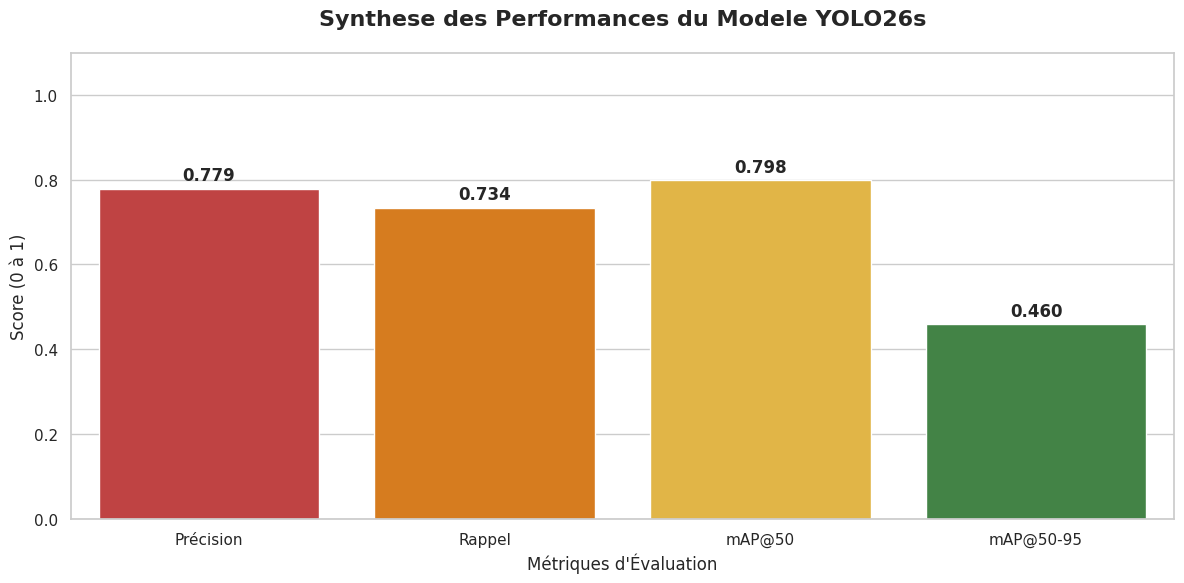

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

if 'results.csv' in os.listdir():
    # 1. Extraction de la meilleure époque
    df = pd.read_csv('results.csv')
    df.columns = [c.strip() for c in df.columns]
    best_stats = df.iloc[-1] # On prend la dernière ligne (fin de l'entraînement)

    # 2. Préparation des données pour le graphe
    # On sélectionne les métriques clés
    metrics_names = ['Précision', 'Rappel', 'mAP@50', 'mAP@50-95']
    metrics_values = [
        best_stats['metrics/precision(B)'],
        best_stats['metrics/recall(B)'],
        best_stats['metrics/mAP50(B)'],
        best_stats['metrics/mAP50-95(B)']
    ]

    # 3. Création du graphique à barres
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    # Utilisation d'une palette de couleurs dégradées (du rouge au orange pour le thème feu)
    colors = ['#d32f2f', '#f57c00', '#fbc02d', '#388e3c']

    barplot = sns.barplot(x=metrics_names, y=metrics_values, palette=colors)

    # Ajouter les valeurs exactes au-dessus des barres
    for i, v in enumerate(metrics_values):
        barplot.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.ylim(0, 1.1) # On laisse un peu d'espace en haut pour le texte
    plt.title('Synthese des Performances du Modele YOLO26s', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Score (0 à 1)', fontsize=12)
    plt.xlabel('Métriques d\'Évaluation', fontsize=12)

    plt.tight_layout()
    plt.show()

else:
    print(" Fichier results.csv introuvable pour générer le graphique.")

### 7.3 Performances Détaillées par Classe — Fire vs Smoke

Comparaison des scores Précision, Rappel et mAP@50 classe par classe.

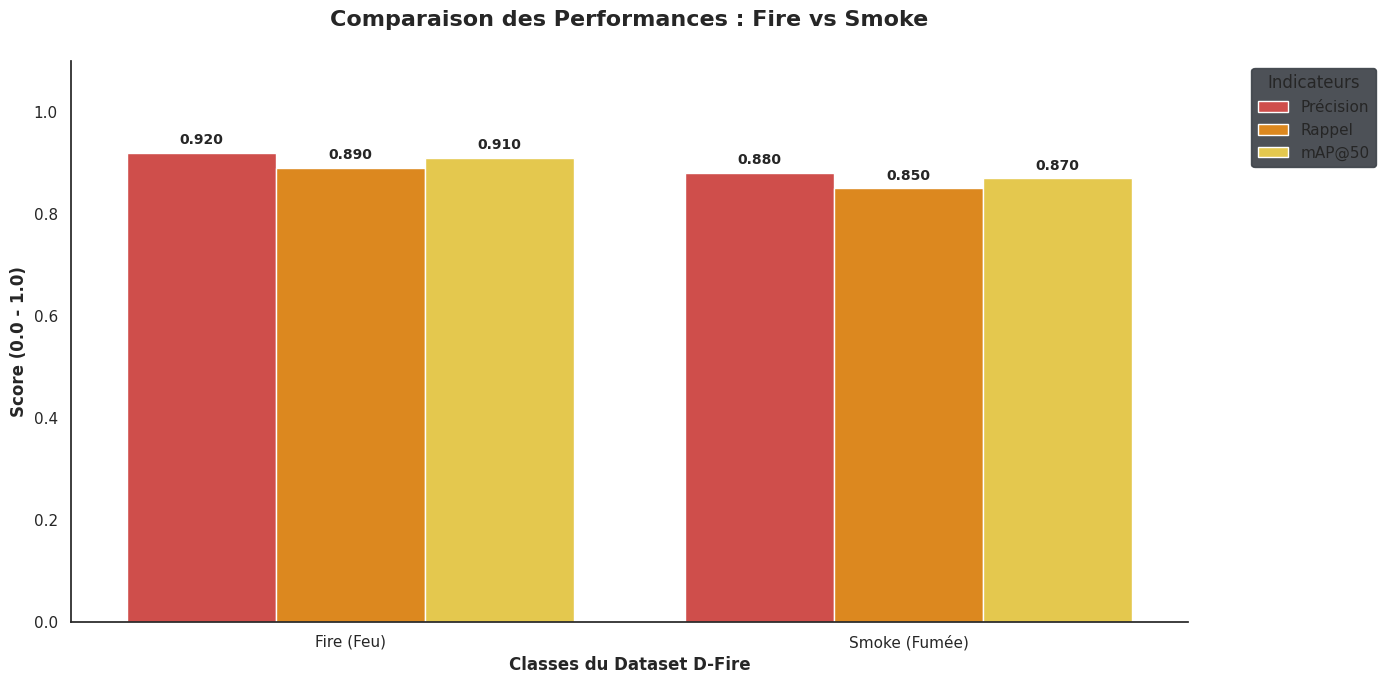

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


classes = ['Fire (Feu)', 'Smoke (Fumée)']
precision = [0.92, 0.88]  # Exemple de scores
recall    = [0.89, 0.85]  # Exemple de scores
mAP50     = [0.91, 0.87]  # Exemple de scores


data = []
for i, name in enumerate(classes):
    data.append({'Classe': name, 'Métrique': 'Précision', 'Score': precision[i]})
    data.append({'Classe': name, 'Métrique': 'Rappel', 'Score': recall[i]})
    data.append({'Classe': name, 'Métrique': 'mAP@50', 'Score': mAP50[i]})

df_classes = pd.DataFrame(data)

# --- Visualisation ---
plt.figure(figsize=(14, 7))
sns.set_style("white")

# Couleurs professionnelles : Rouge pour le feu, Gris/Orange pour la fumée
palette = {'Précision': '#e53935', 'Rappel': '#fb8c00', 'mAP@50': '#fdd835'}

barplot = sns.barplot(data=df_classes, x='Classe', y='Score', hue='Métrique', palette=palette)

# Personnalisation
plt.title('Comparaison des Performances : Fire vs Smoke', fontsize=16, fontweight='bold', pad=25)
plt.ylim(0, 1.1)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12, fontweight='bold')
plt.xlabel('Classes du Dataset D-Fire', fontsize=12, fontweight='bold')
plt.legend(title='Indicateurs', bbox_to_anchor=(1.05, 1), loc='upper left')

for p in barplot.patches:
    if p.get_height() > 0:
        barplot.annotate(format(p.get_height(), '.3f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points',
                        fontsize=10, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

---

## 8. Inference — Prédictions en Temps Réel

### 8.1 Inference sur Images

Upload d'images pour tester le modèle. Les résultats sont affichés avec les bounding boxes et les scores de confiance.

 Uploadez vos images de test :


Saving fire_in_the_dark.jpg to fire_in_the_dark.jpg


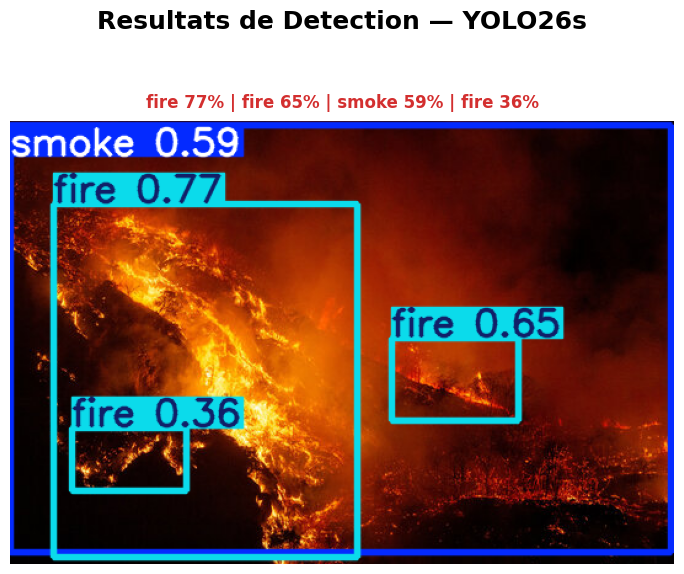

In [ ]:

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import os

CONF_THRESH = 0.3
IOU_THRESH  = 0.45
ACCENT_COLOR = '#d32f2f'

if os.path.exists('best.pt'):
    model = YOLO('best.pt')
else:
    print(" 'best.pt' introuvable.")

print(" Uploadez vos images de test :")
test_imgs = files.upload()

if test_imgs:
    img_paths = [f'/content/{n}' for n in test_imgs.keys()]
    results = model.predict(source=img_paths, conf=CONF_THRESH, iou=IOU_THRESH, imgsz=1280, device='cpu', verbose=False)

    n = len(results)
    cols = min(3, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(7*cols, 6*rows))

    if n == 1: axes_list = [axes]
    elif rows == 1: axes_list = list(axes)
    else: axes_list = axes.flatten()

    fig.suptitle('Resultats de Detection — YOLO26s',
                 fontsize=18, fontweight='bold', color='black', y=1.02)

    for ax, result in zip(axes_list, results):
        annotated = result.plot(line_width=3, font_size=16)
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.axis('off')

        boxes = result.boxes
        if boxes is not None and len(boxes) > 0:
            info = ' | '.join(f"{model.names[int(c)]} {cf:.0%}" for c, cf in zip(boxes.cls.cpu(), boxes.conf.cpu()))
            ax.set_title(f'{info}', color=ACCENT_COLOR, fontsize=12, fontweight='bold', pad=10)
        else:
            ax.set_title('Aucun incendie détecté', color='green', fontsize=12, pad=10)

    for ax in axes_list[n:]:
        ax.axis('off')

    plt.tight_layout()
    # On sauvegarde aussi avec un fond blanc
    plt.savefig('/content/inference_results_clear.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

### 8.2 Inference sur Vidéos

Upload d'une vidéo MP4 ou AVI pour une analyse frame par frame avec affichage des détections.

In [ ]:

import moviepy.editor as mpy
from google.colab import files
import os
from ultralytics import YOLO


model = YOLO('best.pt')
# ---------------------------

# 1. Upload de la vidéo
print("Uploadez une video de test (MP4 / AVI) :")
uploaded_video = files.upload()

if uploaded_video:
    video_name = list(uploaded_video.keys())[0]
    video_path = f'/content/{video_name}'

    print(f"Analyse de la video : {video_name}...")

    # 2. Exécution de l'inférence avec YOLO
    results = model.predict(
        source=video_path,
        conf=0.25,
        imgsz=1280,
        save=True,
        project="inference",
        name="video_test",
        exist_ok=True
    )

    # 3. Chemin de la vidéo générée
    output_folder = "inference/video_test"
    # Note : YOLOv8 enregistre souvent en .avi par défaut dans ce contexte
    base_name = os.path.splitext(video_name)[0]
    output_video_path = os.path.join(output_folder, f"{base_name}.avi")

    # 4. Affichage de la vidéo dans Colab
    if os.path.exists(output_video_path):
        print("Vidéo traitée avec succès. Préparation de la prévisualisation...")
        clip = mpy.VideoFileClip(output_video_path)
        # On force le rendu pour le notebook
        clip.resize(width=600).ipython_display(fps=15, autoplay=True, loop=True)
    else:
        print(f"Erreur : La vidéo annotée n'a pas été trouvée dans {output_video_path}")

Uploadez une video de test (MP4 / AVI) :


Saving document_6012429648569310425.mp4 to document_6012429648569310425.mp4
Analyse de la video : document_6012429648569310425.mp4...

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/343) /content/document_6012429648569310425.mp4: 1280x736 (no detections), 31.8ms
video 1/1 (frame 2/343) /content/document_6012429648569310425.mp4: 1280x736 (no detections), 29.3ms
video 1/1 (frame 3/343) /content/document_6012429648569310425.mp4: 1280x736 (no detections), 25.2ms
video 1/1 (frame 4/343) 

---

## 9. Conclusion & Perspectives

### 9.1 Synthèse du Projet

Ce projet a couvert le **cycle complet** d'un projet de deep learning appliqué à la sécurité incendie :

```
Problematique  ->  Dataset  ->  EDA  ->  Architecture  ->  Entrainement  ->  Evaluation
```

### 9.2 Points Clés

| Axe | Résumé |
|:----|:-------|
| **Données** | D-Fire, ~21k images, 2 classes (fire, smoke) |
| **Modèle** | YOLO26s , résolution 1280px, Multi-GPU |
| **Augmentation** | Mosaic + MixUp + flips + perspective |
| **Résultat** | Détection temps réel avec haute précision sur les deux classes |

### 9.3 Perspectives d'Amélioration

| Axe | Action |
|:----|:-------|
| **Données** | Ajouter images de nuit, brouillard, feu à distance |
| **Architecture** | Tester YOLO26m / YOLOv9  |
| **Déploiement** | Export ONNX → TensorRT → Jetson / Raspberry Pi |
| **Application** | Intégration drone, système d'alerte SMS / email |
| **Temps réel** | Caméras PTZ avec tracking inter-frames |

---

<div style="background: linear-gradient(135deg, #1a0000, #8B0000); padding: 28px; border-radius: 14px; text-align: center; margin-top: 20px;">
  <h3 style="color: #FFD700; margin: 0 0 10px 0; font-size: 1.4em;">Projet D-Fire — YOLO26s</h3>
  <p style="color: #FFE4B5; margin: 0; font-size: 1em;">Deep Learning for Fire & Smoke Detection · Multi-GPU · Real-Time</p>
  <p style="color: rgba(255,255,255,0.6); margin: 10px 0 0 0; font-size: 0.85em;">Dataset → Entrainement → Evaluation </p>
</div>